In [22]:
# importing the yfinance library to fetch stock data
# load nifty 50 data from yahoo finance
import yfinance as yf
nifty_50 = yf.download("^NSEI", start="2010-01-01", end="2026-03-01")
nifty_50

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0
...,...,...,...,...,...
2026-02-23,25713.000000,25771.449219,25609.349609,25678.400391,313700
2026-02-24,25424.650391,25641.800781,25327.599609,25641.800781,439100


In [43]:
nifty_50

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0
...,...,...,...,...,...
2026-02-23,25713.000000,25771.449219,25609.349609,25678.400391,313700
2026-02-24,25424.650391,25641.800781,25327.599609,25641.800781,439100


In [23]:
# Use only the 'Close' column
close_data = nifty_50[['Close']].values
close_data

array([[ 5232.20019531],
       [ 5277.89990234],
       [ 5281.79980469],
       ...,
       [25482.5       ],
       [25496.55078125],
       [25178.65039062]], shape=(3969, 1))

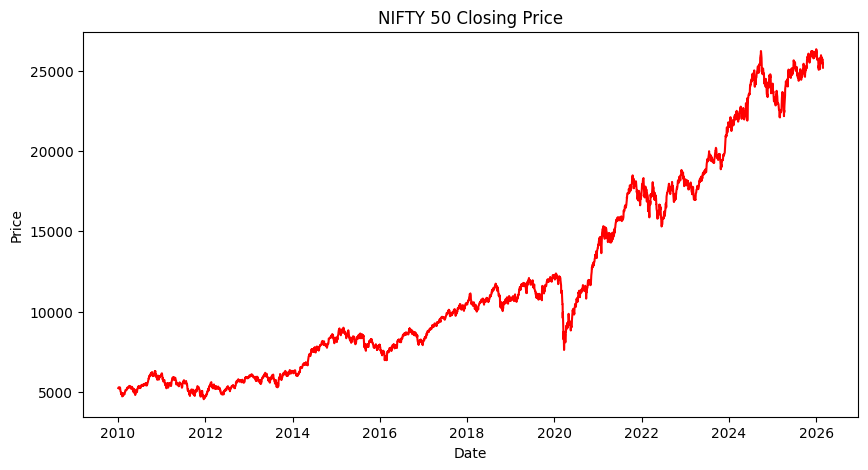

In [24]:
# plotting the closing price of nifty 50
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(nifty_50['Close'], color='red')
plt.title("NIFTY 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [25]:
# normalizing the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(close_data)
data_scaled

array([[0.0315823 ],
       [0.03368013],
       [0.03385915],
       ...,
       [0.96116245],
       [0.96180745],
       [0.94721438]], shape=(3969, 1))

In [26]:
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [27]:
# Create sequences of past 60 days to predict next day price
import numpy as np
def create_sequences(dataset, time_step=60):
    x, y = [], []
    for i in range(time_step, len(dataset)):
        x.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(x), np.array(y)

X_train, y_train = create_sequences(train_data)
X_test, y_test = create_sequences(test_data)

In [28]:
# Reshape for RNN
x_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
x_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [30]:
# build RNN model
def build_rnn():
  model = Sequential()
  model.add(SimpleRNN(50, activation='tanh', input_shape=(60,1)))
  model.add(Dense(40, activation='tanh'))
  model.add(Dense(32, activation='tanh'))
  model.add(Dense(25, activation='tanh'))
  model.add(Dense(10, activation='tanh'))
  model.add(Dense(1, activation='linear'))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

In [31]:
#build an LSTM model
#import LSTM
from tensorflow.keras.layers import LSTM
def build_lstm():
  model=Sequential()
  model.add(LSTM(50, activation='tanh', input_shape=(60,1)))
  model.add(Dense(40, activation='tanh'))
  model.add(Dense(32, activation='tanh'))
  model.add(Dense(25, activation='tanh'))
  model.add(Dense(10, activation='tanh'))
  model.add(Dense(1, activation='linear'))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

In [32]:
# build GRU model
from tensorflow.keras.layers import Dense, GRU
def build_GRU():
  model=Sequential()
  model.add(GRU(50, activation='tanh', input_shape=(60,1)))
  model.add(Dense(40, activation='tanh'))
  model.add(Dense(32, activation='tanh'))
  model.add(Dense(25, activation='tanh'))
  model.add(Dense(10, activation='tanh'))
  model.add(Dense(1, activation='linear'))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

In [33]:
# apply early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [34]:
# train RNN model
history_rnn = build_rnn().fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/20


c:\Users\krish\tf_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0044 - val_loss: 0.0128
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2003e-04 - val_loss: 0.0106
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0701e-04 - val_loss: 0.0118
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.5506e-05 - val_loss: 0.0082
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.0494e-05 - val_loss: 0.0076
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.5308e-05 - val_loss: 0.0112
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5291e-05 - val_loss: 0.0085
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9772e-05 - val_loss: 0.0077
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.1889e-05 - val_loss: 0.0081
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.0579e-05 - val_loss: 0.0119
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.0206e-05 - val_loss: 0.0075
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms

In [35]:
# train LSTM model
lstm_model = build_lstm()
history_lstm = lstm_model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0023 - val_loss: 7.1510e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5.9313e-05 - val_loss: 7.9317e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.9087e-05 - val_loss: 9.2909e-04
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.7012e-05 - val_loss: 5.3978e-04
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.8867e-05 - val_loss: 7.0524e-04
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.9724e-05 - val_loss: 4.9642e-04
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.8685e-05 - val_loss: 0.0015
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8808e-05 - val_loss: 0.0011
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.4886e-05 - val_loss: 9.5286e-04
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.8177e-05 - val_loss: 5.1534e-04
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.2762e-05 - val_loss

In [36]:
# train GRU model
history_gru = build_GRU().fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0027 - val_loss: 0.0033
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.4764e-05 - val_loss: 0.0024
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.2529e-05 - val_loss: 0.0020
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.6759e-05 - val_loss: 0.0018
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.9679e-05 - val_loss: 0.0015
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.1956e-05 - val_loss: 0.0018
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.1193e-05 - val_loss: 0.0016


In [37]:
# Compare final validation losses
models = {
    "RNN":  history_rnn.history['val_loss'][-1],
    "LSTM": history_lstm.history['val_loss'][-1],
    "GRU":  history_gru.history['val_loss'][-1]
}

print(" Final Validation Loss Comparison ")
for name, loss in models.items():
    print(f"{name}:  {loss:.6f}")

best = min(models, key=models.get)
print(f"\n✅ Best Model: {best}")

 Final Validation Loss Comparison 
RNN:  0.006550
LSTM:  0.000511
GRU:  0.001576

✅ Best Model: LSTM


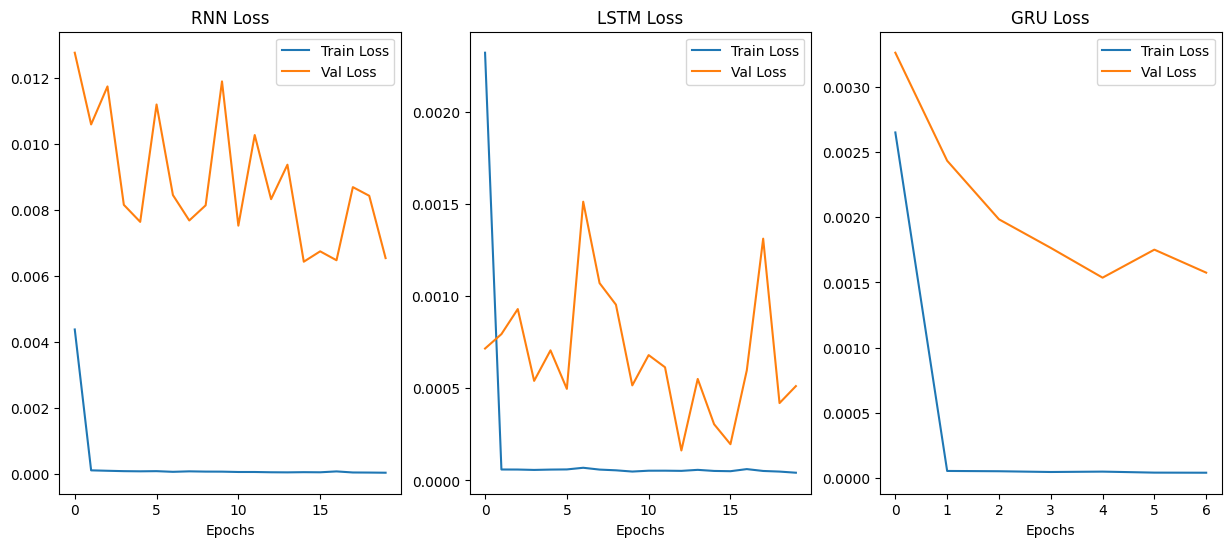

In [38]:
# plot training and validation loss for RNN, LSTM and GRU
plt.figure(figsize=(15,6))
plt.subplot(1, 3, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.xlabel('Epochs')
plt.legend()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


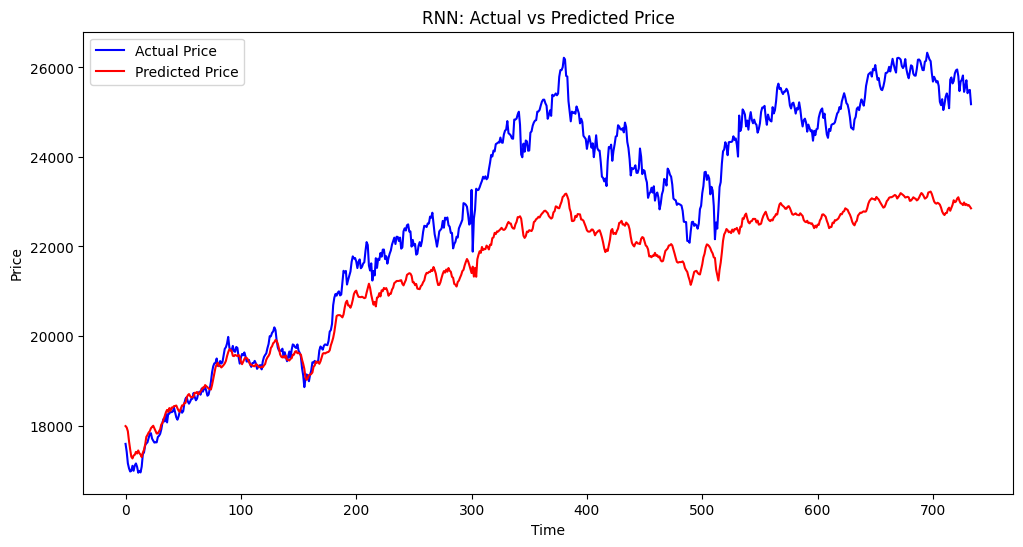

In [39]:
# plot actual vs predicted stock price graph for RNN
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1,1)), color='blue', label='Actual Price')
plt.plot(scaler.inverse_transform(history_rnn.model.predict(x_test)), color='red', label='Predicted Price')
plt.title("RNN: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


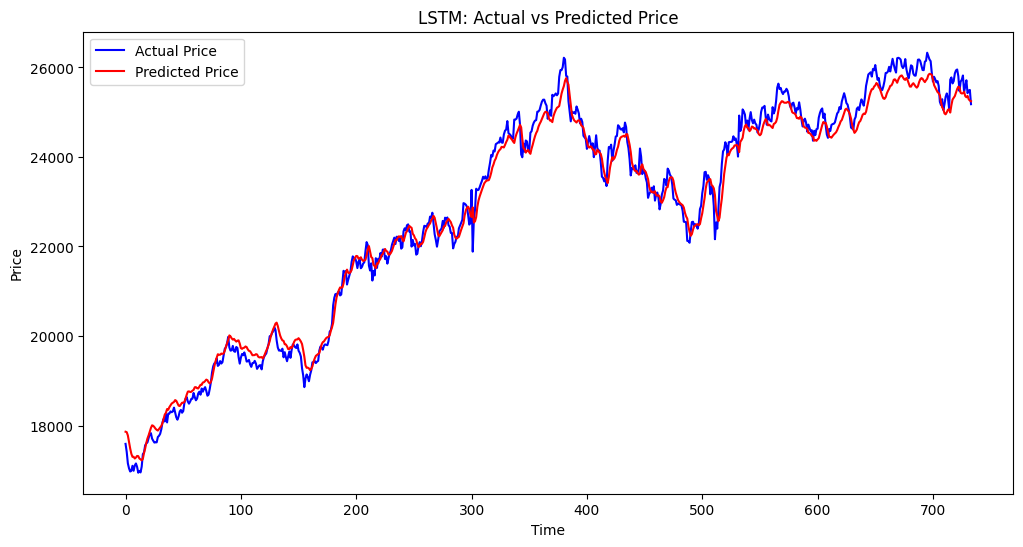

In [40]:
# plot actual vs predicted stock price graph for LSTM
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1,1)), color='blue', label='Actual Price')
plt.plot(scaler.inverse_transform(history_lstm.model.predict(x_test)), color='red', label='Predicted Price')
plt.title("LSTM: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


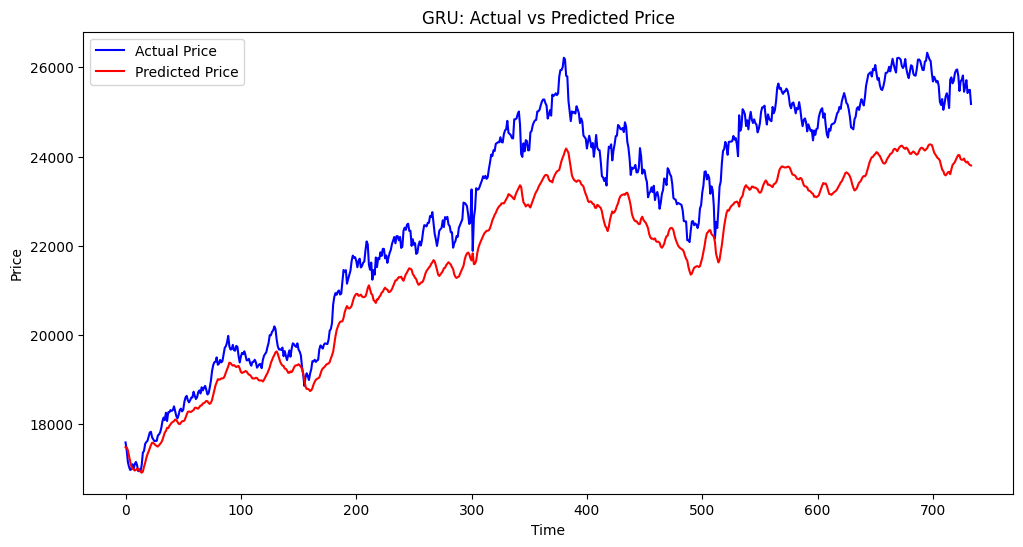

In [41]:
# plot actual vs predicted stock price graph for GRU
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1,1)), color='blue', label='Actual Price')
plt.plot(scaler.inverse_transform(history_gru.model.predict(x_test)), color='red', label='Predicted Price')
plt.title("GRU: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [42]:
import os
import pickle

os.makedirs("model", exist_ok=True)

lstm_model.save("model/lstm_model.keras")

with open("model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
